In [15]:
import pytbl
import busdates
import numpy as np
import pandas as pd
from functools import lru_cache
from rich.progress import track
import xarray as xr
from IPython.display import display, Markdown, Latex
from multiprocess import Pool
import tqdm
import matplotlib.pyplot as plt

In [16]:
major_ret = "ret900.1s"
rets = ['ret60.1s','ret300.1s','ret900.1s','ret1800.1s']
gid_selection = None

In [17]:
@lru_cache(maxsize=128)
def load_one_day(date):
    fn = f"/data/hdd/docker-dataspace/yuheng/rawdata/tick-dump/{date}.tbl"
    return pytbl.tbl_read(fn)

## Notes:
Two new fields has been added here: 
* D-alpha : our alpha baseline
* D.wgtls : our weight - please calculated corr and FR with this weight, as shown below

In [18]:
def work_one_day(date, feature_func):

    df = load_one_day(date).copy()
    if gid_selection is not None:
        df = df[df['gid'].isin(gid_selection)]
    alp_df = feature_func(df).fillna(0)
    alp_df['baseline'] = df['D-alpha']
    wgt = df['D.wgtls'].values
    #calculate corr and FR
    stats_array = []
    for ret in rets:
        xyw = alp_df.multiply(df[ret].values * wgt, axis='index').sum()
        
        yyw = (df[ret]**2).multiply(wgt).sum()
        ds = xr.Dataset({"xyw": xyw,  "yyw": yyw}).rename({"dim_0":"feature"}).expand_dims("ret")
        ds.coords['ret'] = [ret]
        stats_array.append(ds)
    
    ret =  xr.concat(stats_array, dim='ret')

    # calculate sum_k(x_k_i,  x_k_j, w_k), to make my mind easier we are going to use nump
    xval = alp_df.values
    xxw_numpy = np.einsum("ki,kj,k -> ij", xval, xval, wgt)
    xxw = xr.DataArray(xxw_numpy, coords = [alp_df.columns, alp_df.columns], dims=['feature', 'feature2'])
    xxw_diag = xr.DataArray(np.diag(xxw_numpy), coords= [alp_df.columns], dims=['feature'])
    ret['xxw'] = xxw
    ret['xxw_diag'] = xxw_diag
    ret['N'] = np.sum(wgt)
    ret = ret.expand_dims("date")
    ret.coords['date'] = [pd.to_datetime(date)]
    return ret

In [19]:
#corr = sum(x * y) / sqrt(sum(x*x) * sum(y*y))


In [20]:
def work_day_range(start_date, end_date, feature_func):
    dates = busdates.secDates("SHFE", start_date, end_date)
    pool = Pool(processes=16)
    def the_work(date):
        return work_one_day(date, feature_func)
    stats = list(tqdm.tqdm(pool.imap_unordered(the_work, dates), total=len(dates)))
    return xr.concat(stats, dim="date").sortby("date")


In [21]:
# FR = xy / sqrt(xx) = corr * std(y)

In [22]:
def cofit(stats_sum, feature_list):
    XX = (stats_sum['xxw'] / stats_sum['N']).sel(feature = feature_list, feature2 = feature_list).data
    inv_XX = np.linalg.inv(XX)
    XY = (stats_sum['xyw'] / stats_sum['N']).sel(feature=feature_list).sel(ret = major_ret,drop=True).data
    beta = np.einsum("ij,j -> i", inv_XX, XY)
    xyw_arr = stats_sum['xyw'].sel(feature=feature_list).sel(ret=major_ret,drop=True).data
    xxw_arr = stats_sum['xxw'].sel(feature=feature_list, feature2 = feature_list).data
    cofit_FR = np.einsum("i,i->", beta, xyw_arr) / np.sqrt(
        np.einsum("i,ij,j->", beta, xxw_arr, beta) *
        stats_sum['N'].data
    )
    return beta, cofit_FR

In [29]:
def report_from_stat(stats):
    term_stats = stats##.sel(feature = )
    raw_features = [x for x in stats.feature.values if x !="baseline"]
    corr = term_stats['xyw'].sum("date") / np.sqrt(term_stats['xxw_diag'].sum("date") * term_stats['yyw'].sum("date"))
    FR = term_stats['xyw'].sum("date") / np.sqrt(term_stats['xxw_diag'].sum("date") * term_stats['N'].sum("date")) 
    FR_day = term_stats['xyw'] / np.sqrt(term_stats['xxw_diag'] * term_stats['N'])

    #1. show corr and FR table
    display(Markdown("## correlation"))
    display(corr.sel(feature=raw_features).to_dataset("feature").to_dataframe()*1e2)

    display(Markdown("## FR"))
    display(FR.sel(feature=raw_features).to_dataset("feature").to_dataframe()*1e4)

    #2. FR cumsum plot on major_ret
    display(Markdown("## FR cumsum"))
    FR_day_sum = FR_day.sel(feature=raw_features, ret=major_ret).cumsum("date")
    for feature in FR_day_sum.feature:
        plt.plot(FR_day_sum.date, FR_day_sum.sel(feature=feature)*1e4 / len(FR_day_sum.date), label=feature.values)
    plt.legend()
    plt.show()
    plt.close()

    #3. insample cofit with alpha
    display(Markdown("## insample cofit w/ baseline"))
    display(Markdown("note that to fully demonstrate the strength of the new feature, please implement outsample comparison. This and next section is only used to show how fitting is done."))
    stats_sum = stats.sum("date")
    
    feature_list = stats_sum.feature.data
    beta, cofit_FR = cofit(stats_sum, feature_list)
    baseline_FR = FR.sel(ret = major_ret, feature ="baseline").data
    ans = pd.DataFrame([{
        "baseline": baseline_FR * 1e4,
        "cofit": cofit_FR * 1e4
    }])
    ans['improve %'] = (ans['cofit'] / ans['baseline'] - 1 ) * 1e2
    display(ans)
    beta_df = pd.DataFrame({"feature": feature_list, "beta": beta})
    display(beta_df)

    #4. test each feature for cofit
    display(Markdown("## fit each feature with baseline"))
    ans = []
    for feature in raw_features:
        feature_list = [feature, "baseline"]
        beta, cofit_FR = cofit(stats_sum, feature_list)
        ans.append({
            "feature": feature,
            "feater_beta": beta[0],
            "baseline_beta": beta[1],
            "cofit_FR": cofit_FR * 1e4,
            "improve %": (cofit_FR / baseline_FR - 1)*1e2
        })
    display(pd.DataFrame(ans))

In [24]:
def feature_0(df):
    df['mid'] = (df['AskPrice0'] + df['BidPrice0']) / 2
    df['hist_ret_1min'] = -df.groupby("gid")['mid'].diff(60 * 4).fillna(0) / df['mid']
    df['tot_ask'] = df['AskSize0'] + df['AskSize1'] + df['AskSize2'] + df['AskSize3'] + df['AskSize4']
    df['tot_bid'] = df['BidSize0'] + df['BidSize1'] + df['BidSize2'] + df['BidSize3'] + df['BidSize4']
    df['bar5'] = - (df['tot_ask'] - df['tot_bid']) / (df['tot_ask']+df['tot_bid'])
    df['bar'] = - (df['AskSize0'] - df['BidSize0']) / (df['AskSize0']+df['BidSize0'])
    return df[['hist_ret_1min', 'bar', 'bar5']]

In [25]:
stats_all = work_day_range("20220101", "20220801", feature_0)

  0%|          | 0/139 [00:00<?, ?it/s]

100%|██████████| 139/139 [00:25<00:00,  5.36it/s]


## correlation

,hist_ret_1min,bar,bar5
ret,,,
ret60.1s,0.221536,0.229802,0.519579
ret300.1s,0.156006,-0.058677,0.330334
ret900.1s,-0.216432,-0.183659,-0.015541
ret1800.1s,-0.448736,-0.183736,-0.594286


## FR

,hist_ret_1min,bar,bar5
ret,,,
ret60.1s,0.024248,0.025153,0.056871
ret300.1s,0.034703,-0.013053,0.073483
ret900.1s,-0.079481,-0.067445,-0.005707
ret1800.1s,-0.229909,-0.094137,-0.304482


## FR cumsum

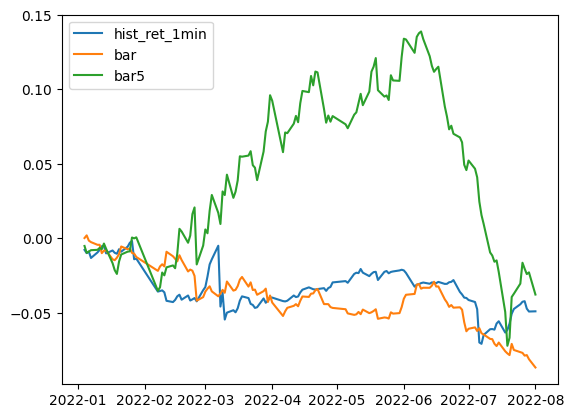

## insample cofit w/ baseline

note that to fully demonstrate the strength of the new feature, please implement outsample comparison. This and next section is only used to show how fitting is done.

,baseline,cofit,improve %
0,1.668555,1.670985,0.145632


,feature,beta
0,hist_ret_1min,-0.000632
1,bar,-0.000017
2,bar5,-0.000011
3,baseline,0.974888


## fit each feature with baseline

,feature,feater_beta,baseline_beta,cofit_FR,improve %
0,hist_ret_1min,-0.000670,0.974132,1.669078,0.031328
1,bar,-0.000020,0.974857,1.670201,0.098669
2,bar5,-0.000018,0.975661,1.669487,0.055865


In [30]:
report_from_stat(stats_all)

# Universe

sid,symbol,type,ex,tick_size,lot_size,multiplier,name,sdate,edate,wgt.sh50,wgt.hs300,wgt.zz500,univ

900004,AU,FUTURE,SHFE,0.05,1000,0,沪金,0,0,,,,nonx

900009,CF,FUTURE,CZCE,5,5,0,郑棉,0,0,,,,nonx

900014,FG,FUTURE,CZCE,1,20,0,玻璃,0,0,,,,nonx

900023,JM,FUTURE,DCE,0.5,60,0,焦煤,0,0,,,,nonx

900027,M,FUTURE,DCE,1,10,0,豆粕,0,0,,,,nonx

900031,OI,FUTURE,CZCE,2,10,0,菜油,0,0,,,,nonx

900032,P,FUTURE,DCE,2,10,0,棕榈油,0,0,,,,nonx

900036,RB,FUTURE,SHFE,1,10,0,螺纹钢,0,0,,,,nonx

900041,RU,FUTURE,SHFE,5,10,0,橡胶,0,0,,,,nonx

900044,SN,FUTURE,SHFE,10,1,0,沪锡,0,0,,,,nonx

900045,SR,FUTURE,CZCE,1,10,0,白糖,0,0,,,,nonx

900059,AP,FUTURE,CZCE,1,10,1,苹果,0,0,,,,nonx